# Análise Exploratória — Detecção de Fraude em Cartão de Crédito

Dataset: [Credit Card Fraud Detection (ULB MLG)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

Variáveis `V1`–`V28` são componentes PCA (dados anonimizados). `Class`: 0 = transação normal, 1 = fraude.

# 0. Importações e carregar dataset

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "creditcard.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Verificar o formato do dataset
df.shape

## 1. Visão geral dos dados

In [ ]:
# Verificar tipos
df.info()

Linhas: 284,807 | Colunas: 31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non

Acima se vê que todas as variáveis são numéricas

In [ ]:
missing = df.isnull().sum()
print("Valores ausentes por coluna:")
print(missing[missing > 0] if missing.any() else "Não há nenhum valor ausente.")

Valores ausentes por coluna:
Nenhum valor ausente.


In [ ]:
# Distribuição das features
df.describe().T

## 2. Distribuição da variável alvo (desbalanceamento)

,count,percent
Normal (0),NaN,NaN
Fraude (1),NaN,NaN


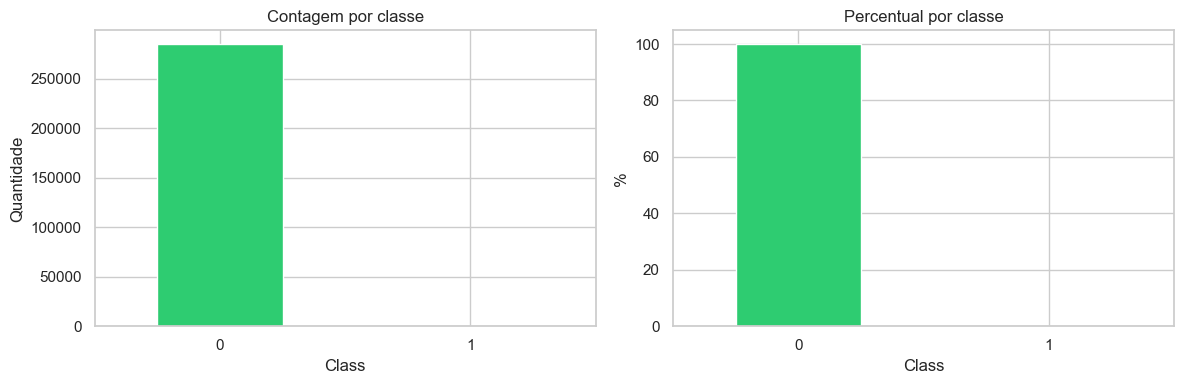

Razão normal/fraude: 577.9:1


In [6]:
df["Class"] = pd.to_numeric(df["Class"], errors="coerce").astype(int)

class_counts = df["Class"].value_counts().sort_index()
class_pct = df["Class"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "count": class_counts.values,
    "percent": class_pct.round(4).values,
}, index=["Normal (0)", "Fraude (1)"])
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind="bar", ax=ax[0], color=["#2ecc71", "#e74c3c"], rot=0)
ax[0].set_title("Contagem por classe")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Quantidade")

class_pct.plot(kind="bar", ax=ax[1], color=["#2ecc71", "#e74c3c"], rot=0)
ax[1].set_title("Percentual por classe")
ax[1].set_ylabel("%")
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts[0] / class_counts[1]
print(f"Razão normal/fraude: {imbalance_ratio:.1f}:1")

## 3. Variável Amount

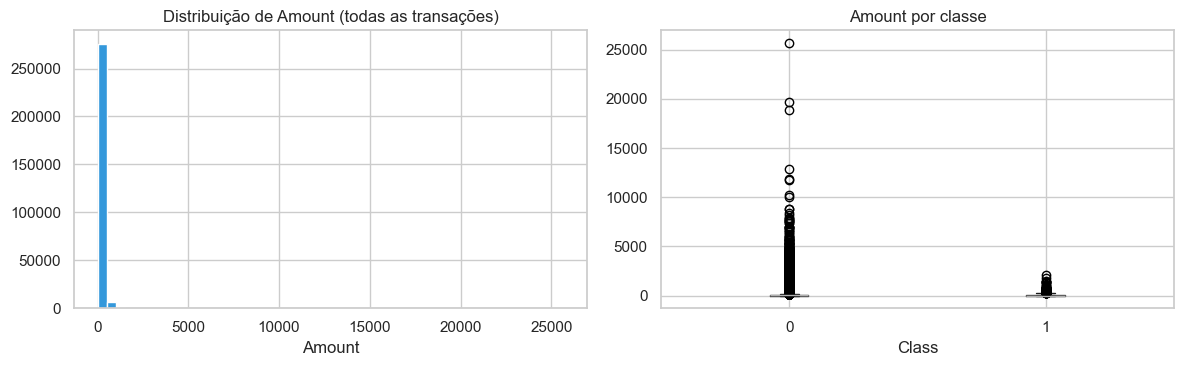

,mean,median,std,max
Class,,,,
0,88.291022,22.00,250.105092,25691.16
1,122.211321,9.25,256.683288,2125.87


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Amount"].hist(bins=50, ax=axes[0], color="#3498db", edgecolor="white")
axes[0].set_title("Distribuição de Amount (todas as transações)")
axes[0].set_xlabel("Amount")

df.boxplot(column="Amount", by="Class", ax=axes[1])
axes[1].set_title("Amount por classe")
axes[1].set_xlabel("Class")
plt.suptitle("")
plt.tight_layout()
plt.show()

df.groupby("Class")["Amount"].agg(["mean", "median", "std", "max"])

## 4. Variável Time

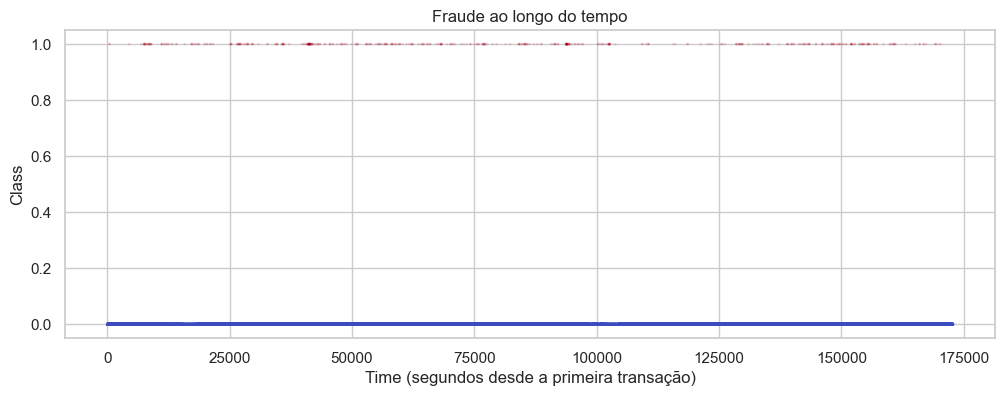

hour_bucket
0     2
1     2
2    21
3    13
4     6
5    11
6     3
7    23
8     5
9    15
Name: count, dtype: int64

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(df["Time"], df["Class"], alpha=0.1, s=1, c=df["Class"], cmap="coolwarm")
ax.set_xlabel("Time (segundos desde a primeira transação)")
ax.set_ylabel("Class")
ax.set_title("Fraude ao longo do tempo")
plt.show()

fraud_by_hour = df[df["Class"] == 1].copy()
fraud_by_hour["hour_bucket"] = (fraud_by_hour["Time"] // 3600).astype(int)
fraud_by_hour["hour_bucket"].value_counts().sort_index().head(10)

## 5. Features V1–V28 (PCA)

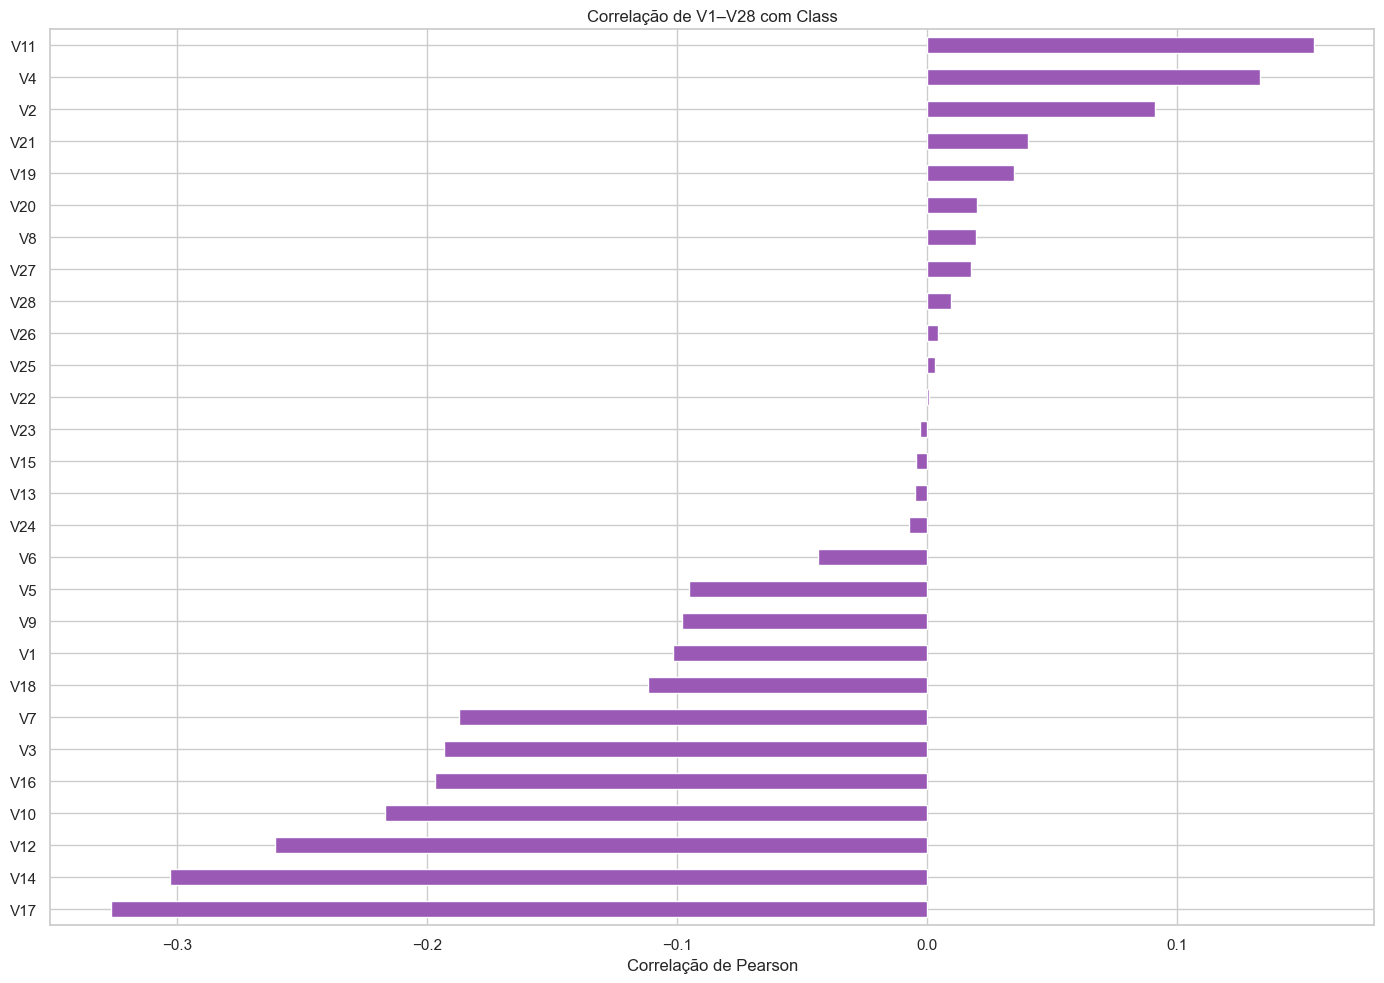

Features com maior |correlação| com Class: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']


In [9]:
v_cols = [c for c in df.columns if c.startswith("V")]

fig, ax = plt.subplots(figsize=(14, 10))
corr = df[v_cols + ["Class"]].corr()["Class"].drop("Class").sort_values()
corr.plot(kind="barh", ax=ax, color="#9b59b6")
ax.set_title("Correlação de V1–V28 com Class")
ax.set_xlabel("Correlação de Pearson")
plt.tight_layout()
plt.show()

top_features = corr.abs().sort_values(ascending=False).head(10).index.tolist()
print("Top 10 features com maior |correlação| com Class:")
for i, feat in enumerate(top_features, 1):
    print(f"  {i:2d}. {feat}  (r={corr[feat]:.4f})")

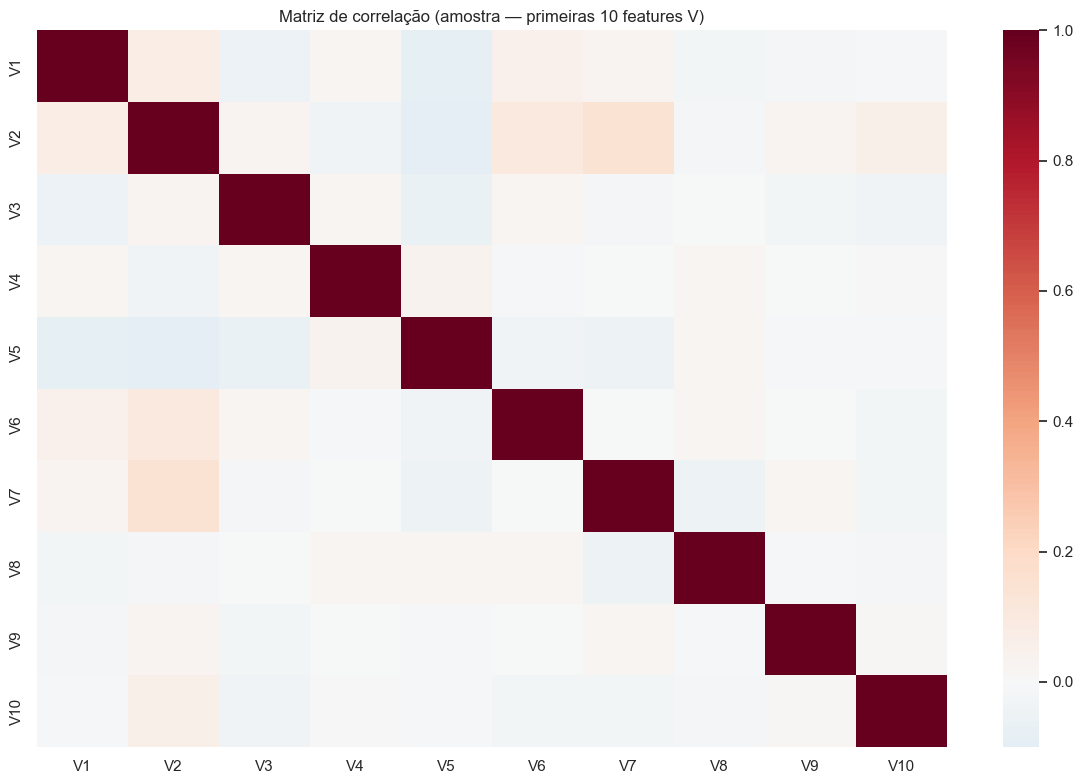

In [10]:
sample = df.sample(n=min(5000, len(df)), random_state=42)
plt.figure(figsize=(12, 8))
sns.heatmap(sample[v_cols[:10]].corr(), annot=False, cmap="RdBu_r", center=0)
plt.title("Matriz de correlação (amostra — primeiras 10 features V)")
plt.tight_layout()
plt.show()

## 6. Distribuição das top 10 features por classe

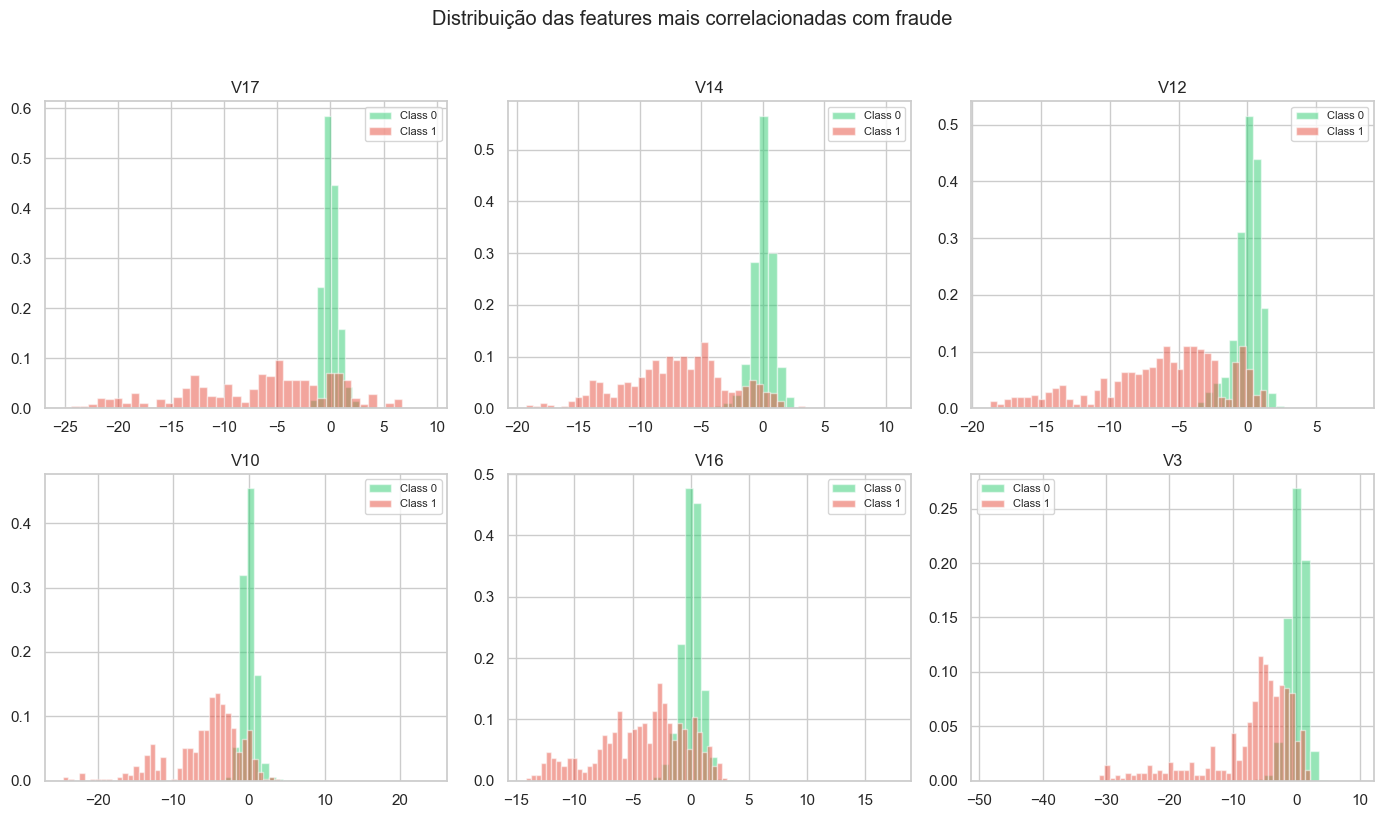

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    for label, color in [(0, "#2ecc71"), (1, "#e74c3c")]:
        subset = df.loc[df["Class"] == label, col]
        ax.hist(subset, bins=40, alpha=0.5, label=f"Class {label}", color=color, density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)

plt.suptitle("Top 10 features — distribuição por classe", y=1.02)
plt.tight_layout()
plt.show()

## 7. Resumo e próximos passos

- O dataset é **fortemente desbalanceado** (~0,17% de fraudes).
- Não há valores ausentes nas colunas originais.
- `Amount` e `Time` podem ajudar, mas as features **V1–V28** concentram o sinal (PCA).
- Para modelagem: estratificar o split, considerar `class_weight='balanced'` ou técnicas de reamostragem, e priorizar **recall** e **ROC-AUC** em vez de acurácia.
- Baseline: `python scripts/train_logistic_regression.py`